In [19]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from optuna.integration import CatBoostPruningCallback
from sklearn.model_selection import KFold
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, root_mean_squared_error, r2_score, mean_squared_error
import matplotlib.pyplot as plt
import seaborn as sns

import optuna as optuna
import xgboost as xgb
import lightgbm as lgb

In [20]:
# 1️⃣ Load your DataFrame
df = pd.read_csv('data/data_cleaned.csv') 

results = []

# 2️⃣ Features and target
# y = np.log1p(df['price'])
# X = df.drop(columns=['price'])

# 3️⃣ Train/Validation/Test Split
# X_train_full, X_test, y_train_full, y_test = train_test_split(
#     X, y, test_size=0.15, random_state=42
# )
# X_train, X_val, y_train, y_val = train_test_split(
#     X_train_full, y_train_full, test_size=0.1765, random_state=42
# )  # ~15% of original for val

y = np.log1p(df['price'])
# X = df[['habitablesurface', 'latitude', 'longitude',
#         'epcscore_encoded', 'buildingcondition_encoded', 'region_Brussels','bedroomcount']]
X = df.drop(columns=['price'])


# train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# print(f"Train: {X_train.shape}, Validation: {X_val.shape}, Test: {X_test.shape}")


In [3]:
# 4️⃣ StandardScaler for linear models
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


In [4]:
# 5️⃣ Helper function
def evaluate_model(name, model, X_test, y_test, X_train, y_train):
    # Predict in log space
    y_pred_test = model.predict(X_test)
    y_pred_train = model.predict(X_train)

    # Convert back to EUR
    y_test_eur = np.expm1(y_test)
    y_pred_test_eur = np.expm1(y_pred_test)
    y_train_eur = np.expm1(y_train)
    y_pred_train_eur = np.expm1(y_pred_train)

    # Calculate metrics in EUR space
    test_mae = mean_absolute_error(y_test_eur, y_pred_test_eur)
    test_rmse = root_mean_squared_error(y_test_eur, y_pred_test_eur)
    test_r2 = r2_score(y_test_eur, y_pred_test_eur)

    train_mae = mean_absolute_error(y_train_eur, y_pred_train_eur)
    train_rmse = root_mean_squared_error(y_train_eur, y_pred_train_eur)
    train_r2 = r2_score(y_train_eur, y_pred_train_eur)

    print(f"\n{name} Evaluation:")
    print(f"Test MAE: {test_mae:,.2f} EUR")
    print(f"Test RMSE: {test_rmse:,.2f} EUR")
    print(f"Test R^2: {test_r2:.4f}")
    
    print(f"Train MAE: {train_mae:,.2f} EUR")
    print(f"Train RMSE: {train_rmse:,.2f} EUR")
    print(f"Train R^2: {train_r2:.4f}\n")

    # Scatter plot for visual sanity check
    plt.figure(figsize=(6, 6))
    plt.scatter(y_test_eur, y_pred_test_eur, alpha=0.3)
    plt.xlabel('Actual Price')
    plt.ylabel('Predicted Price')
    plt.title('Actual vs Predicted Price')
    plt.plot([y_test_eur.min(), y_test_eur.max()], [y_test_eur.min(), y_test_eur.max()], 'r--')
    plt.tight_layout()
    plt.show()

    results.append({
    "Model":name,
    "Test MAE": test_mae,
    "Test RMSE": test_rmse,
    "Test R^2": test_r2,
    "Train MAE": train_mae,
    "Train RMSE": train_rmse,
    "Train R^2": train_r2
})



Random Forest Evaluation:
Test MAE: 61,017.74 EUR
Test RMSE: 87,303.71 EUR
Test R^2: 0.7068
Train MAE: 23,767.12 EUR
Train RMSE: 36,137.56 EUR
Train R^2: 0.9499



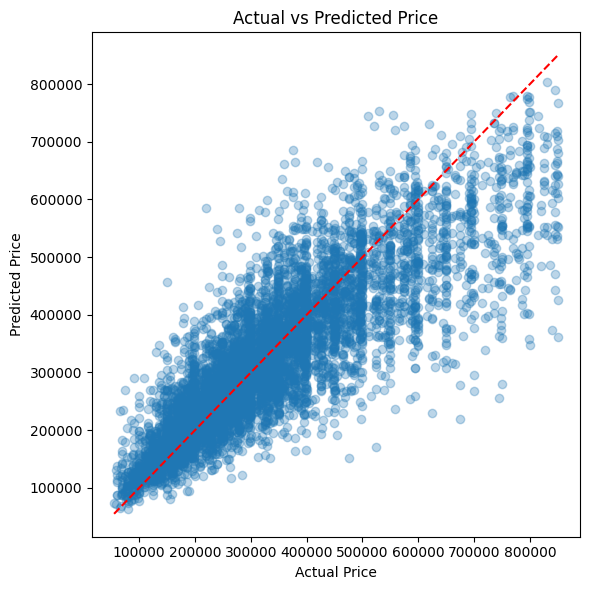

In [5]:

## Random Forest
rf = RandomForestRegressor()
rf.fit(X_train, y_train)
evaluate_model("Random Forest", rf, X_test, y_test, X_train, y_train)


XGBoost Evaluation:
Test MAE: 58,717.83 EUR
Test RMSE: 83,886.38 EUR
Test R^2: 0.7293
Train MAE: 49,371.33 EUR
Train RMSE: 70,673.69 EUR
Train R^2: 0.8086



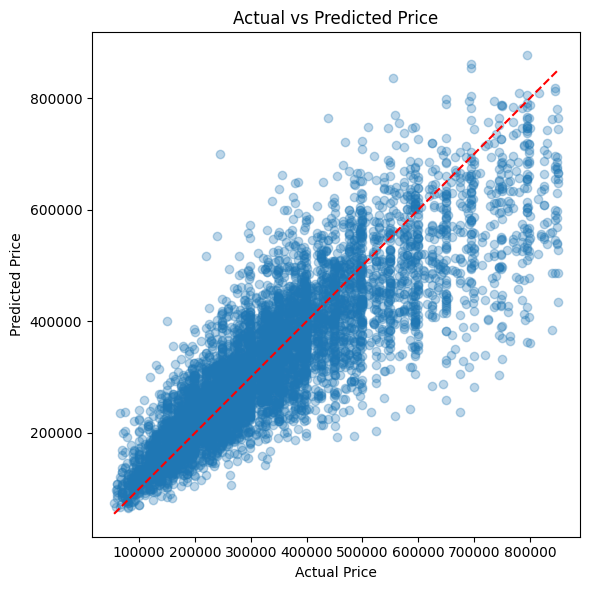

In [6]:
## XGBoost
xgbr = xgb.XGBRegressor(n_estimators=100, random_state=42, n_jobs=-1)
xgbr.fit(X_train, y_train)
evaluate_model("XGBoost", xgbr, X_test, y_test, X_train, y_train)

[LightGBM] [Warning] early_stopping_round is set=50, early_stopping_rounds=50 will be ignored. Current value: early_stopping_round=50
[LightGBM] [Warning] feature_fraction is set=0.9, colsample_bytree=0.8 will be ignored. Current value: feature_fraction=0.9
[LightGBM] [Warning] feature_fraction is set=0.9, colsample_bytree=0.8 will be ignored. Current value: feature_fraction=0.9
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000926 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1095
[LightGBM] [Info] Number of data points in the train set: 28260, number of used features: 16
[LightGBM] [Warning] early_stopping_round is set=50, early_stopping_rounds=50 will be ignored. Current value: early_stopping_round=50
[LightGBM] [Warning] feature_fraction is set=0.9, colsample_bytree=0.8 will be ignored. Current value: feature_fraction=0.9
[LightG

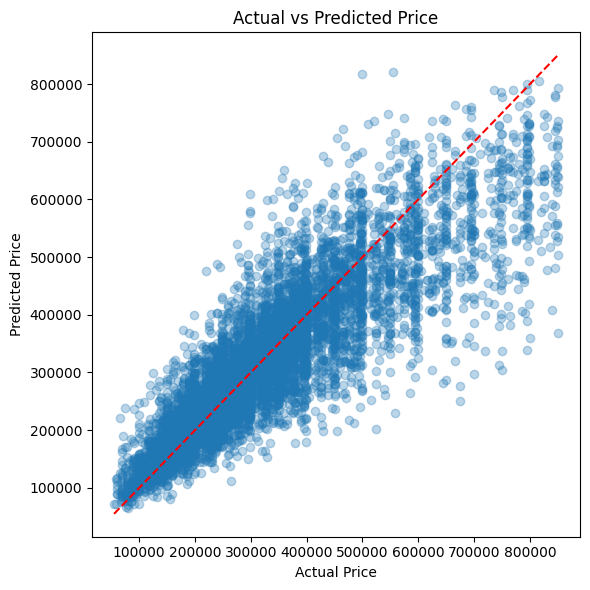

                         Feature  Importance
1               habitablesurface        5019
13                      latitude        3745
14                     longitude        3535
15  distance_to_province_capital        2914
7               epcscore_encoded        1636
0                   bedroomcount        1238
8      buildingcondition_encoded        1190
16                region_cluster        1097
6                     hasparking         499
5                     hasterrace         465
3                      hasgarden         383
2                        haslift         320
12                  type_encoded         281
10               region_Flanders          93
4                hasswimmingpool          76
11               region_Wallonia           9
9                region_Brussels           0


In [7]:

lgb_model = lgb.LGBMRegressor(
    objective='regression',
    metric='rmse',
    boosting_type='gbdt',
    n_estimators=1000,
    learning_rate=0.05,
    num_leaves=31,
    max_depth=-1,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1,
    early_stopping_rounds=50,
    feature_fraction=0.9,
)

# ✅ Fit with early stopping
lgb_model.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    eval_metric='rmse',
)


evaluate_model("LightGBM", lgb_model, X_test, y_test, X_train, y_train)



# ✅ Feature importance for interpretability
importance = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': lgb_model.feature_importances_
}).sort_values(by='Importance', ascending=False)

print(importance)

#  !! Performing worse with top features!

# top_features = [
#     'habitablesurface',
#     'latitude',
#     'epcscore_encoded',
#     'longitude',
#     'buildingcondition_encoded',
#     "bedroomcount",
#     # 'region_Brussels',
#     # 'haslift',
#     # 'hasswimmingpool',
#     # 'hasparking'
# ]

# X_train_top = X_train[top_features]
# X_test_top = X_test[top_features]
# y_pred_log = lgb_model.predict(X_test)
# y_pred = np.expm1(y_pred_log)          # back to EUR
# y_test_actual = np.expm1(y_test)     # back to EUR

# lgb_model.fit(
#     X_train_top, y_train,
#     eval_set=[(X_test_top, y_test)],
#     eval_metric='rmse',
# )

# mae = mean_absolute_error(y_test_actual, y_pred)
# rmse = root_mean_squared_error(y_test_actual, y_pred)
# r2 = r2_score(y_test_actual, y_pred)
# print(f"LightGBM  MAE: {mae:,.2f} EUR")
# print(f"LightGBM  RMSE: {rmse:,.2f} EUR")
# print(f"LightGBM  R^2: {r2:.4f}\n")


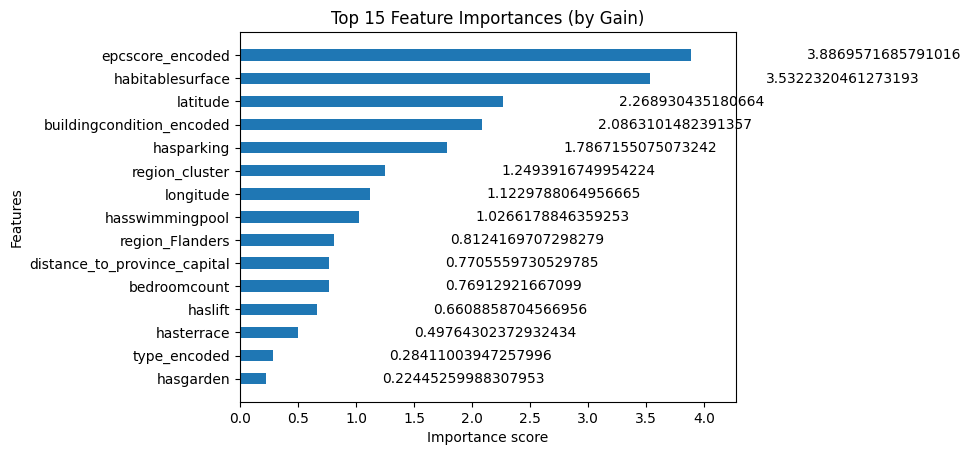

In [8]:
# 7️⃣ Feature Importance Plots (for tree models)

def plot_feature_importance(model, model_name, feature_names):
    importances = model.feature_importances_
    sorted_idx = np.argsort(importances)
    plt.figure(figsize=(8, 6))
    plt.barh(range(len(sorted_idx)), importances[sorted_idx], align='center')
    plt.yticks(range(len(sorted_idx)), [feature_names[i] for i in sorted_idx])
    plt.title(f"{model_name} Feature Importances")
    plt.show()

# plot_feature_importance(rf, "Random Forest", X.columns)
# plot_feature_importance(xgbr, "XGBoost", X.columns)
# plot_feature_importance(lgbmr, "LightGBM", X.columns)

# Plot top 15 features by gain
xgb.plot_importance(
    xgbr,
    importance_type='gain',
    max_num_features=15,   # adjust as needed
    height=0.5,
    grid=False
)
plt.title("Top 15 Feature Importances (by Gain)")
plt.show()


                         Feature      Gain
0               epcscore_encoded  3.886957
1               habitablesurface  3.532232
2                       latitude  2.268930
3      buildingcondition_encoded  2.086310
4                     hasparking  1.786716
5                 region_cluster  1.249392
6                      longitude  1.122979
7                hasswimmingpool  1.026618
8                region_Flanders  0.812417
9   distance_to_province_capital  0.770556
10                  bedroomcount  0.769129
11                       haslift  0.660886
12                    hasterrace  0.497643
13                  type_encoded  0.284110
14                     hasgarden  0.224453

XGBoost (Top Features) Evaluation:
Test MAE: 52,658.30 EUR
Test RMSE: 75,322.27 EUR
Test R^2: 0.7825
Train MAE: 61,082.18 EUR
Train RMSE: 87,222.65 EUR
Train R^2: 0.7074



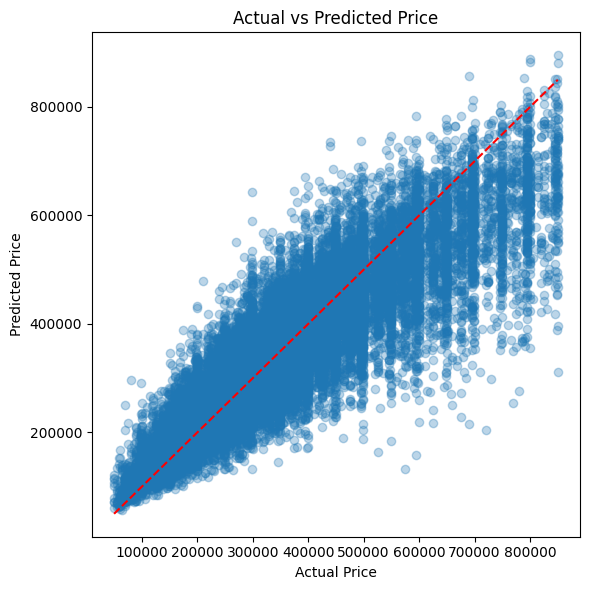

In [9]:
booster = xgbr.get_booster()
gain_scores = booster.get_score(importance_type='gain')

# Convert to DataFrame for analysis
import pandas as pd

gain_df = pd.DataFrame({
    'Feature': list(gain_scores.keys()),
    'Gain': list(gain_scores.values())
})

# Sort descending
gain_df = gain_df.sort_values(by='Gain', ascending=False).reset_index(drop=True)
print(gain_df)


top_features = [
    'region_Brussels',
    'habitablesurface',
    'buildingcondition_encoded',
    'latitude',
    'epcscore_encoded',
    # 'haslift',
    # 'hasswimmingpool',
    'longitude',
    'hasparking'
]

X_train_top = X_train[top_features]
X_test_top = X_test[top_features]

xgb_model_top = xgb.XGBRegressor(n_estimators=100, random_state=42, n_jobs=-1)
xgb_model_top.fit(X_train_top, y_train)

evaluate_model("XGBoost (Top Features)",xgb_model_top,  X_train_top, y_train, X_test_top, y_test)


In [10]:
# Don't do this. Takes too long and doesn't improve performance.

# def objective(trial):
#     param = {
#         'max_depth': trial.suggest_int('max_depth', 3, 12),
#         'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3),
#         'n_estimators': trial.suggest_int('n_estimators', 100, 1000),
#         'subsample': trial.suggest_float('subsample', 0.6, 1.0),
#         'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
#         'gamma': trial.suggest_float('gamma', 0, 5),
#         'reg_alpha': trial.suggest_float('reg_alpha', 0, 5),
#         'reg_lambda': trial.suggest_float('reg_lambda', 0, 5),
#         'random_state': 42,
#         'n_jobs': -1,
#         "early_stopping_rounds":50, 
#     }

#     kf = KFold(n_splits=5, shuffle=True, random_state=42)
#     rmses = []
#     for train_idx, val_idx in kf.split(X_train):
#         X_tr, X_val = X_train.iloc[train_idx], X_train.iloc[val_idx]
#         y_tr, y_val = y_train.iloc[train_idx], y_train.iloc[val_idx]

#         model = xgb.XGBRegressor(**param)
#         model.fit(X_tr, y_tr, eval_set=[(X_val, y_val)])
#         preds = model.predict(X_val)
#         rmse = root_mean_squared_error(np.expm1(y_val), np.expm1(preds))
#         rmses.append(rmse)
#     return np.mean(rmses)

# study = optuna.create_study(direction='minimize')
# study.optimize(objective, n_trials=50)

# print("Best trial:")
# trial = study.best_trial
# print(f"  RMSE: {trial.value}")
# print("  Best hyperparameters: ")
# for key, value in trial.params.items():
#     print(f"    {key}: {value}")

In [11]:
# # use trial.params to get the best hyperparameters from the study
# xgb_model_top = xgb.XGBRegressor(**trial.params)
# # xgb_model_top = xgb.XGBRegressor()
# xgb_model_top.fit(X_train_top, y_train)

# evaluate_model("XGBoost (Top Features)", xgb_model_top, X_test_top, y_test, X_train_top, y_train)


In [12]:
# ✅ CatBoost pipeline 
from catboost import CatBoostRegressor, Pool
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import pandas as pd
import numpy as np

# -------------------
# Assuming you already have:
# X_train, X_val, X_test, y_train, y_val, y_test prepared
# -------------------

# ✅ Instantiate CatBoost with a solid baseline hyperparameter set
cat_model = CatBoostRegressor(
    iterations=1000,
    learning_rate=0.05,
    depth=6,
    l2_leaf_reg=3,
    loss_function='RMSE',
    eval_metric='RMSE',
    random_seed=42,
    verbose=50,
    early_stopping_rounds=50
)

# ✅ Fit using Pool (recommended for CatBoost)
train_pool = Pool(X_train, y_train)
test_pool = Pool(X_test, y_test)

cat_model.fit(train_pool, eval_set=test_pool)

# ✅ Feature importance for interpretability
importance = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': cat_model.get_feature_importance()
}).sort_values(by='Importance', ascending=False)

print(importance)


0:	learn: 0.4774911	test: 0.4796938	best: 0.4796938 (0)	total: 58.8ms	remaining: 58.7s
50:	learn: 0.2894778	test: 0.2904877	best: 0.2904877 (50)	total: 140ms	remaining: 2.61s
100:	learn: 0.2613274	test: 0.2614012	best: 0.2614012 (100)	total: 222ms	remaining: 1.98s
150:	learn: 0.2514498	test: 0.2512439	best: 0.2512439 (150)	total: 306ms	remaining: 1.72s
200:	learn: 0.2461221	test: 0.2460532	best: 0.2460532 (200)	total: 389ms	remaining: 1.55s
250:	learn: 0.2419682	test: 0.2422128	best: 0.2422128 (250)	total: 472ms	remaining: 1.41s
300:	learn: 0.2386574	test: 0.2395850	best: 0.2395850 (300)	total: 552ms	remaining: 1.28s
350:	learn: 0.2359530	test: 0.2375313	best: 0.2375313 (350)	total: 632ms	remaining: 1.17s
400:	learn: 0.2337673	test: 0.2360182	best: 0.2360182 (400)	total: 715ms	remaining: 1.07s
450:	learn: 0.2318622	test: 0.2349283	best: 0.2349283 (450)	total: 797ms	remaining: 970ms
500:	learn: 0.2301651	test: 0.2339106	best: 0.2339106 (500)	total: 879ms	remaining: 876ms
550:	learn: 0.2


CatBoost (Tuned) Evaluation:
Test MAE: 57,528.63 EUR
Test RMSE: 82,398.88 EUR
Test R^2: 0.7388
Train MAE: 54,553.57 EUR
Train RMSE: 78,216.19 EUR
Train R^2: 0.7655



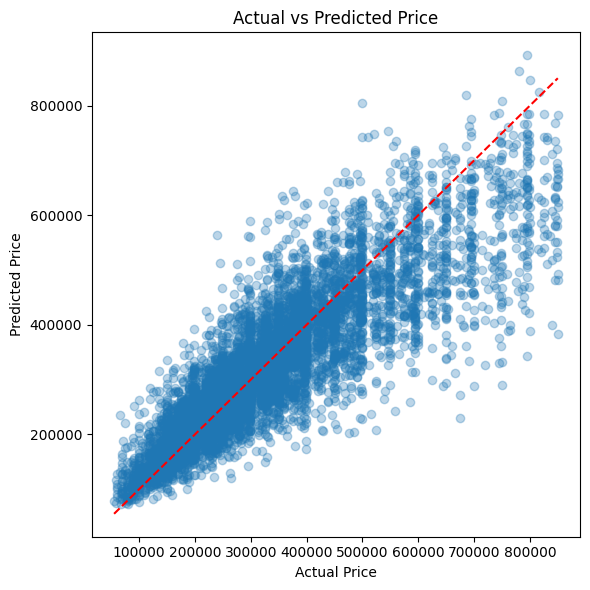

In [17]:
# Run evaluation
evaluate_model("CatBoost (Tuned)", cat_model,  X_test, y_test, X_train, y_train,)

0:	learn: 0.4773377	test: 0.4795504	best: 0.4795504 (0)	total: 2.49ms	remaining: 2.49s
50:	learn: 0.2892010	test: 0.2906193	best: 0.2906193 (50)	total: 71.4ms	remaining: 1.33s
100:	learn: 0.2639180	test: 0.2646268	best: 0.2646268 (100)	total: 137ms	remaining: 1.22s
150:	learn: 0.2553403	test: 0.2557807	best: 0.2557807 (150)	total: 204ms	remaining: 1.14s
200:	learn: 0.2505370	test: 0.2513886	best: 0.2513886 (200)	total: 270ms	remaining: 1.07s
250:	learn: 0.2469194	test: 0.2482730	best: 0.2482730 (250)	total: 334ms	remaining: 998ms
300:	learn: 0.2440476	test: 0.2458282	best: 0.2458282 (300)	total: 398ms	remaining: 925ms
350:	learn: 0.2416363	test: 0.2440470	best: 0.2440470 (350)	total: 466ms	remaining: 861ms
400:	learn: 0.2396747	test: 0.2427605	best: 0.2427605 (400)	total: 529ms	remaining: 790ms
450:	learn: 0.2377677	test: 0.2414683	best: 0.2414683 (450)	total: 594ms	remaining: 723ms
500:	learn: 0.2362257	test: 0.2406509	best: 0.2406509 (500)	total: 658ms	remaining: 655ms
550:	learn: 0.

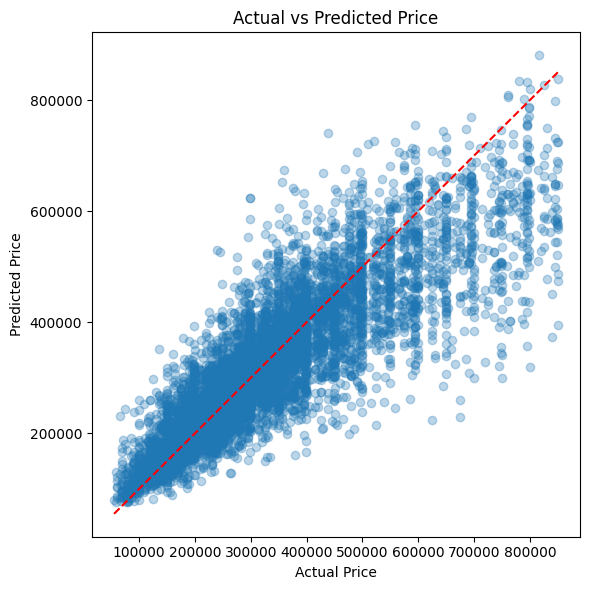

In [18]:
# Same as above, but with top features
top_features = [
    'habitablesurface',
    'latitude',
    'longitude',
    'epcscore_encoded',
    'buildingcondition_encoded',
    'bedroomcount',
    'region_cluster',
    'hasparking',
    'region_Flanders'
]
X_train_top = X_train[top_features]
X_test_top = X_test[top_features]
cat_model_top = CatBoostRegressor(
    iterations=1000,
    learning_rate=0.05,
    depth=6,
    l2_leaf_reg=3,
    loss_function='RMSE',
    eval_metric='RMSE',
    random_seed=42,
    verbose=50,
    early_stopping_rounds=50
)
train_pool_top = Pool(X_train_top, y_train)
test_pool_top = Pool(X_test_top, y_test)
cat_model_top.fit(train_pool_top, eval_set=test_pool_top)
evaluate_model("CatBoost (Top Features)", cat_model_top, X_test_top, y_test, X_train_top, y_train)

In [14]:
# Don't do this. Takes too long and doesn't improve performance.

# import optuna
# from catboost import CatBoostRegressor, Pool
# from sklearn.metrics import mean_squared_error

# def get_params(trial):
#     return {
#         "iterations": 2000,
#         "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.1, log=True),
#         "depth": trial.suggest_int("depth", 4, 10),
#         "l2_leaf_reg": trial.suggest_float("l2_leaf_reg", 1, 10),
#         "subsample": trial.suggest_float("subsample", 0.6, 1.0),
#         "bagging_temperature": trial.suggest_float("bagging_temperature", 0, 1),
#         "random_strength": trial.suggest_float("random_strength", 1e-9, 10.0, log=True),
#         "border_count": trial.suggest_int("border_count", 32, 255),
#         "loss_function": "RMSE",
#         "eval_metric": "RMSE",
#         "verbose": 0,
#         "random_seed": 42,
#         "early_stopping_rounds": 50
#     }

# def objective(trial):
#     params = get_params(trial)
#     model = CatBoostRegressor(**params)
#     model.fit(Pool(X_train, y_train),
#               eval_set=Pool(X_val, y_val),
#               verbose=0)

#     preds = model.predict(X_val)
#     rmse = root_mean_squared_error(y_val, preds)
#     return rmse

# def objective_with_cv(trial):
#     params = get_params(trial)
#     model = CatBoostRegressor(**params)
#     kf = KFold(n_splits=5, shuffle=True, random_state=42)
#     rmses = []
#     for train_idx, val_idx in kf.split(X_train):
#         X_tr, X_val_fold = X_train.iloc[train_idx], X_train.iloc[val_idx]
#         y_tr, y_val_fold = y_train.iloc[train_idx], y_train.iloc[val_idx]

#         model.fit(Pool(X_tr, y_tr),
#                   eval_set=Pool(X_val_fold, y_val_fold),
#                   verbose=0)

#         preds = model.predict(X_val_fold)
#         rmse = root_mean_squared_error(y_val_fold, preds)
#         rmses.append(rmse)

#     return np.mean(rmses)

# study = optuna.create_study(direction="minimize")
# study.optimize(objective_with_cv, n_trials=50, show_progress_bar=True)

# print("Best RMSE:", study.best_value)
# print("Best hyperparameters:", study.best_params)



CatBoost Evaluation:
Test MAE: 57,528.63 EUR
Test RMSE: 82,398.88 EUR
Test R^2: 0.7388
Train MAE: 54,553.57 EUR
Train RMSE: 78,216.19 EUR
Train R^2: 0.7655



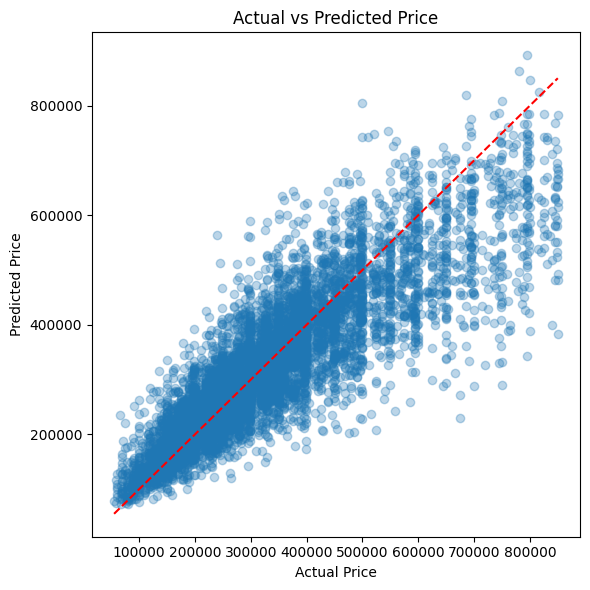

                         Feature  Importance
1               habitablesurface   28.289599
13                      latitude   20.087485
14                     longitude   11.071781
7               epcscore_encoded    9.690865
8      buildingcondition_encoded    7.362401
15  distance_to_province_capital    5.298797
0                   bedroomcount    5.250568
16                region_cluster    4.725989
6                     hasparking    3.092645
11               region_Wallonia    1.400082
10               region_Flanders    0.828814
2                        haslift    0.823849
12                  type_encoded    0.758528
5                     hasterrace    0.594553
4                hasswimmingpool    0.447927
3                      hasgarden    0.276117
9                region_Brussels    0.000000


In [15]:

from catboost import CatBoostRegressor, Pool
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import pandas as pd
import numpy as np


# ✅ Instantiate CatBoost 
cat_model = CatBoostRegressor(
# **study.best_params
iterations=500, learning_rate=0.1, depth=6, verbose=0
)

# ✅ Fit using Pool (recommended for CatBoost)
train_pool = Pool(X_train, y_train)
test_pool = Pool(X_test, y_test)

cat_model.fit(train_pool, eval_set=test_pool)

evaluate_model("CatBoost", cat_model, X_test, y_test, X_train, y_train)

# ✅ Feature importance for interpretability
importance = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': cat_model.get_feature_importance()
}).sort_values(by='Importance', ascending=False)

print(importance)

y_test_actual = np.expm1(y_test)



In [16]:
results_df = pd.DataFrame(results)
print(results_df)

                    Model      Test MAE     Test RMSE  Test R^2     Train MAE  \
0           Random Forest  61017.736464  87303.711208  0.706809  23767.115032   
1                 XGBoost  58717.833796  83886.377560  0.729312  49371.328904   
2                LightGBM  57412.058131  82194.711570  0.740120  50186.880935   
3  XGBoost (Top Features)  52658.296215  75322.265262  0.782540  61082.184644   
4                CatBoost  57323.861501  82164.267531  0.740312  54582.885596   
5                CatBoost  57528.634268  82398.880641  0.738827  54553.568665   

     Train RMSE  Train R^2  
0  36137.561230   0.949945  
1  70673.692865   0.808553  
2  72196.989927   0.800211  
3  87222.653062   0.707353  
4  78307.218637   0.764963  
5  78216.186647   0.765509  
